<a href="https://colab.research.google.com/github/bhattacharyyad/Debnath_Code/blob/master/Animal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow numpy pillow matplotlib

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predictions for lion.jpg:
1: lion (0.84)
2: chow (0.01)
3: Tibetan_mastiff (0.00)


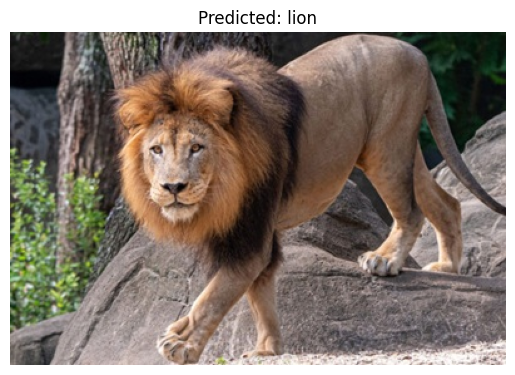

In [10]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load the pre-trained MobileNetV2 model
model = MobileNetV2(weights='imagenet')

def recognize_animal(img_path):
    # 2. Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # 3. Make prediction
    predictions = model.predict(x)

    # 4. Decode and print top 3 predictions
    decoded = decode_predictions(predictions, top=3)[0]

    print(f"Predictions for {img_path}:")
    for i, (imagenet_id, label, score) in enumerate(decoded):
        print(f"{i + 1}: {label} ({score:.2f})")

    # Display image
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Predicted: {decoded[0][1]}")
    plt.axis('off')
    plt.show()

# Execution: recognize_animal('my_lion_picture.jpg')
recognize_animal('lion.jpg')
